<a href="https://colab.research.google.com/github/pravee827/DataScience-and-Data-Analysis-with-python/blob/main/TASK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

M

/tmp/ipykernel_4074/434024671.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_4074/434024671.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

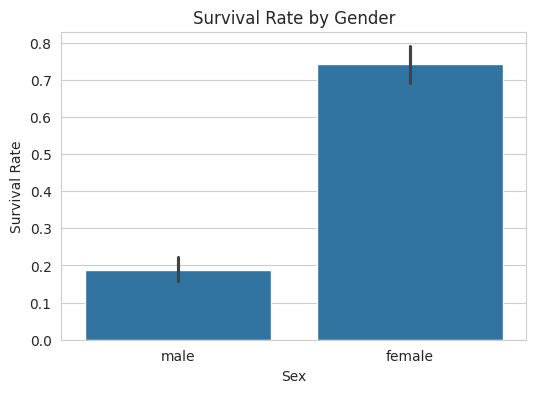

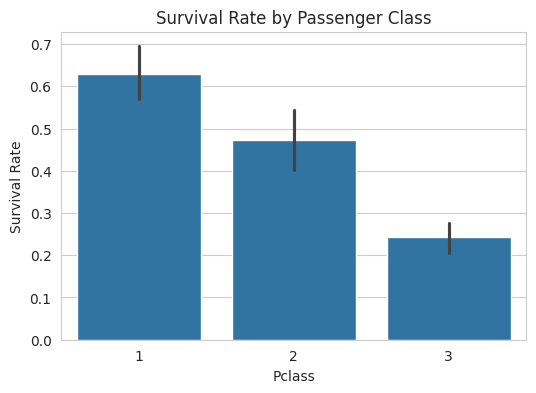

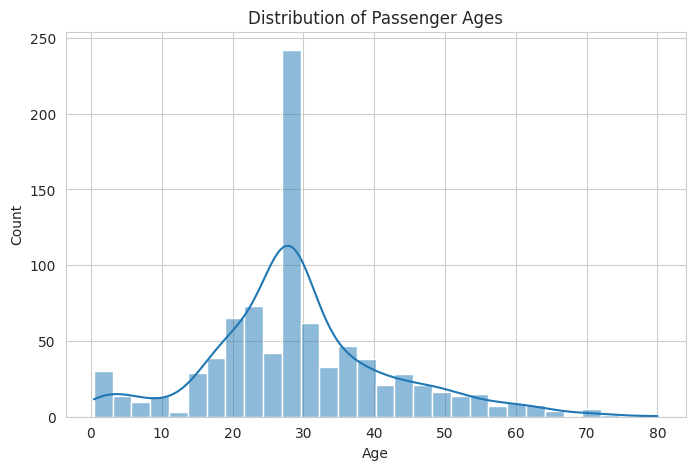


Insights:
1. Females had higher survival rates than males.
2. First-class passengers had better survival chances.
3. Younger passengers showed comparatively better survival rates.


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
# Download train.csv from Kaggle Titanic Dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")

# Display first 5 rows
print(df.head())

# ==============================
# Data Cleaning
# ==============================

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing Age values with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked missing values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column because too many missing values
df.drop(columns='Cabin', inplace=True)

# Verify missing values again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ==============================
# Survival Analysis
# ==============================

# Survival count by gender
gender_survival = df.groupby('Sex')['Survived'].mean()
print("\nSurvival Rate by Gender:")
print(gender_survival)

# Survival count by passenger class
class_survival = df.groupby('Pclass')['Survived'].mean()
print("\nSurvival Rate by Passenger Class:")
print(class_survival)

# ==============================
# Age Group Analysis
# ==============================

# Create age groups
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Survival rate by age group
age_survival = df.groupby('Age_Group')['Survived'].mean()
print("\nSurvival Rate by Age Group:")
print(age_survival)

# ==============================
# Data Visualization
# ==============================

sns.set_style("whitegrid")

# 1. Survival by Gender
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

# 2. Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

# 3. Histogram of Passenger Ages
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# ==============================
# Final Insights
# ==============================

print("\nInsights:")
print("1. Females had higher survival rates than males.")
print("2. First-class passengers had better survival chances.")
print("3. Younger passengers showed comparatively better survival rates.")